# CSP-9-Distributed : CSP Distribués (DisCSP)

**Navigation** : [<< CSP-8-Temporal](CSP-8-Temporal.ipynb) | [Index](../README.md) | [App-1-NQueens >>](../Applications/CSP/App-1-NQueens.ipynb)

> **Durée estimée** : 2h00

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. **Comprendre** les défis de la résolution distribuée de CSP
2. **Implémenter** l'algorithme Asynchronous Backtracking (ABT)
3. **Découvrir** Asynchronous Weak-Commitment (AWC) et ses améliorations
4. **Appliquer** les techniques de privacy-preserving CSP
5. **Résoudre** des problèmes de coordination multi-agent


In [1]:
# Imports
from dataclasses import dataclass, field
from typing import Dict, List, Set, Tuple, Optional, Any
from enum import Enum
from collections import defaultdict
import random
import asyncio
from datetime import datetime
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

print("Environnement prepare pour les CSP Distribues")

Environnement prepare pour les CSP Distribues


## 1. Formalisation du DisCSP

### Definition

Un **DisCSP** (Distributed Constraint Satisfaction Problem) est defini par :

- **Agents** : $A = \{a_1, a_2, ..., a_n\}$
- **Variables** : Chaque agent $a_i$ controle un sous-ensemble $X_i \subset X$
- **Domaines** : Chaque variable $x_j$ a un domaine $D_j$
- **Contraintes** : $C = C_{interne} \cup C_{externe}$
  - $C_{interne}$ : contraintes entre variables d'un meme agent
  - $C_{externe}$ : contraintes entre variables d'agents differents

### Hypotheses classiques

1. **Un agent = une variable** (simplification courante)
2. **Communication asynchrone** : pas de synchronisation globale
3. **Fiabilite** : messages arrives dans l'ordre, sans perte
4. **Ordre total** : priorite entre agents (ABT)

In [2]:
@dataclass
class Message:
    """Message echange entre agents dans un DisCSP."""
    sender: int          # ID de l'agent emetteur
    receiver: int        # ID de l'agent destinataire
    msg_type: str        # 'ok?', 'nogood', 'addlink', 'stop'
    content: Any         # Contenu du message
    timestamp: float = field(default_factory=lambda: datetime.now().timestamp())
    
    def __repr__(self):
        return f"Message({self.sender}->{self.receiver}, {self.msg_type})"


@dataclass
class Nogood:
    """Nogood : ensemble d'assignations incoherentes."""
    assignments: Dict[int, Any]  # {var_id: value}
    
    def __repr__(self):
        pairs = [f"x{v}={val}" for v, val in self.assignments.items()]
        return f"NG({', '.join(pairs)})"
    
    def __hash__(self):
        return hash(tuple(sorted(self.assignments.items())))
    
    def __eq__(self, other):
        return self.assignments == other.assignments

## 2. Asynchronous Backtracking (ABT)

### Principe

ABT (Yokoo, Durfee, Ishida, Kuwabara, 1992) est l'algorithme de reference pour DisCSP :

1. **Ordre total** : Les agents sont ordonnes $a_1 < a_2 < ... < a_n$
2. **Propagation avant** : Les agents de haute priorite envoient leurs valeurs
3. **Nogoods** : Les agents de basse priorite generent des explications d'echec
4. **Asynchronie** : Chaque agent traite les messages independamment

### Types de messages ABT

| Message | Direction | Contenu |
|---------|-----------|---------|
| `ok?` | Haute -> Basse priorite | Assignation courante |
| `nogood` | Basse -> Haute priorite | Contrainte apprise |
| `addlink` | Basse -> Haute priorite | Demande de connexion |
| `stop` | N'importe quel agent | Solution trouvee ou impossible |

In [3]:
class ABTAgent:
    """
    Agent pour l'algorithme Asynchronous Backtracking.
    
    Base sur Yokoo et al. (1992)
    """
    
    def __init__(self, agent_id: int, domain: List[Any], 
                 constraint_func, neighbors: List[int]):
        self.id = agent_id
        self.domain = domain
        self.constraint_func = constraint_func  # Fonction de contrainte locale
        self.neighbors = neighbors
        
        # Etat de l'agent
        self.value = None
        self.agent_view: Dict[int, Any] = {}  # Vue des agents de haute priorite
        self.nogoods: Set[Nogood] = set()     # Nogoods appris
        self.higher_priority: List[int] = []  # Agents de haute priorite
        self.lower_priority: List[int] = []   # Agents de basse priorite
        
        # File de messages
        self.message_queue: List[Message] = []
        
        # Statistiques
        self.messages_sent = 0
        self.nogoods_generated = 0
    
    def set_priority_order(self, higher: List[int], lower: List[int]):
        """Definit l'ordre de priorite des agents."""
        self.higher_priority = higher
        self.lower_priority = lower
    
    def check_consistency(self, value: Any) -> bool:
        """Verifie si une valeur est coherente avec l'agent_view."""
        # Verifier avec l'agent_view
        for var_id, val in self.agent_view.items():
            if not self.constraint_func(self.id, value, var_id, val):
                return False
        
        # Verifier avec les nogoods
        for nogood in self.nogoods:
            # Si le nogood est applicable (toutes les vars dans agent_view)
            if self._nogood_applicable(nogood, value):
                return False
        
        return True
    
    def _nogood_applicable(self, nogood: Nogood, value: Any) -> bool:
        """Verifie si un nogood elimine la valeur courante."""
        for var_id, val in nogood.assignments.items():
            if var_id == self.id:
                if val == value:
                    # Verifier que les autres variables correspondent
                    for v, v_val in nogood.assignments.items():
                        if v != self.id and self.agent_view.get(v) != v_val:
                            return False
                    return True
        return False
    
    def choose_value(self) -> Optional[Any]:
        """Choisit une valeur coherente avec l'agent_view."""
        for val in self.domain:
            if self.check_consistency(val):
                return val
        return None
    
    def process_ok_message(self, msg: Message):
        """Traite un message 'ok?' (assignation d'un agent de haute priorite)."""
        var_id, value = msg.content
        self.agent_view[var_id] = value
        
        # Verifier si la valeur courante est toujours valide
        if self.value is not None and not self.check_consistency(self.value):
            self.value = self.choose_value()
            if self.value is not None:
                return self._send_ok_messages()
            else:
                return self._backtrack()
        return []
    
    def process_nogood_message(self, msg: Message) -> List[Message]:
        """Traite un message 'nogood' (contrainte apprise)."""
        nogood = msg.content
        self.nogoods.add(nogood)
        self.nogoods_generated += 1
        
        # Verifier si de nouveaux liens sont necessaires
        new_links = []
        for var_id in nogood.assignments:
            if var_id != self.id and var_id not in self.agent_view:
                if var_id not in self.higher_priority:
                    # Ajouter aux agents de haute priorite
                    self.higher_priority.append(var_id)
                    new_links.append(var_id)
        
        messages = []
        
        # Envoyer addlink si necessaire
        for var_id in new_links:
            messages.append(Message(
                sender=self.id,
                receiver=var_id,
                msg_type='addlink',
                content=self.id
            ))
            self.messages_sent += 1
        
        # Verifier la valeur courante
        if self.value is not None and not self.check_consistency(self.value):
            self.value = self.choose_value()
            if self.value is not None:
                messages.extend(self._send_ok_messages())
            else:
                messages.extend(self._backtrack())
        
        return messages
    
    def _send_ok_messages(self) -> List[Message]:
        """Envoie la valeur courante aux agents de basse priorite."""
        messages = []
        for neighbor in self.lower_priority:
            messages.append(Message(
                sender=self.id,
                receiver=neighbor,
                msg_type='ok?',
                content=(self.id, self.value)
            ))
            self.messages_sent += 1
        return messages
    
    def _backtrack(self) -> List[Message]:
        """Genere un nogood et l'envoie a l'agent de haute priorite responsable."""
        if not self.higher_priority:
            # Pas de solution
            return [Message(
                sender=self.id,
                receiver=-1,  # Broadcast
                msg_type='stop',
                content='no_solution'
            )]
        
        # Construire un nogood a partir de l'agent_view
        nogood_assignments = dict(self.agent_view)
        nogood_assignments[self.id] = self.value if self.value else self.domain[0]
        nogood = Nogood(nogood_assignments)
        
        # Envoyer au plus haut agent dans le nogood
        target = max(nogood.assignments.keys())
        if target == self.id:
            target = max([v for v in nogood.assignments if v != self.id])
        
        return [Message(
            sender=self.id,
            receiver=target,
            msg_type='nogood',
            content=nogood
        )]
    
    def initialize(self) -> List[Message]:
        """Initialise l'agent et envoie les premiers messages."""
        self.value = self.choose_value()
        if self.value is not None:
            return self._send_ok_messages()
        return []

In [4]:
class ABTSystem:
    """
    Systeme de simulation pour l'algorithme ABT.
    Simule la communication asynchrone entre agents.
    """
    
    def __init__(self, agents: Dict[int, ABTAgent]):
        self.agents = agents
        self.message_queue: List[Message] = []
        self.solution: Optional[Dict[int, Any]] = None
        self.no_solution = False
        self.total_messages = 0
        self.total_nogoods = 0
        
        # Initialiser l'ordre de priorite
        self._setup_priority_order()
    
    def _setup_priority_order(self):
        """Configure l'ordre de priorite pour chaque agent."""
        agent_ids = sorted(self.agents.keys())
        for i, agent_id in enumerate(agent_ids):
            higher = agent_ids[:i]
            lower = agent_ids[i+1:]
            self.agents[agent_id].set_priority_order(higher, lower)
    
    def run(self, max_iterations: int = 1000) -> Optional[Dict[int, Any]]:
        """Execute l'algorithme ABT jusqu'a convergence."""
        # Phase d'initialisation
        for agent in self.agents.values():
            messages = agent.initialize()
            self.message_queue.extend(messages)
        
        # Boucle principale
        iteration = 0
        while iteration < max_iterations and self.message_queue:
            # Prendre le prochain message
            msg = self.message_queue.pop(0)
            self.total_messages += 1
            
            if msg.msg_type == 'stop':
                self.no_solution = True
                return None
            
            # Traiter le message
            receiver = self.agents.get(msg.receiver)
            if receiver:
                if msg.msg_type == 'ok?':
                    new_messages = receiver.process_ok_message(msg)
                elif msg.msg_type == 'nogood':
                    new_messages = receiver.process_nogood_message(msg)
                    self.total_nogoods += 1
                elif msg.msg_type == 'addlink':
                    # Ajouter le lien (simplifie)
                    new_messages = []
                else:
                    new_messages = []
                
                self.message_queue.extend(new_messages)
            
            # Verifier convergence
            if self._check_solution():
                self.solution = {a.id: a.value for a in self.agents.values()}
                return self.solution
            
            iteration += 1
        
        return None
    
    def _check_solution(self) -> bool:
        """Verifie si tous les agents ont une valeur coherente."""
        for agent in self.agents.values():
            if agent.value is None:
                return False
            if not agent.check_consistency(agent.value):
                return False
        return True
    
    def get_statistics(self) -> Dict:
        """Retourne les statistiques d'execution."""
        return {
            'total_messages': self.total_messages,
            'total_nogoods': self.total_nogoods,
            'solution_found': self.solution is not None,
            'solution': self.solution
        }

### Exemple : Coloration de graphe distribuee

Considerons un probleme de coloration de graphe ou chaque noeud est un agent independant.

In [5]:
# Exemple : Coloration de graphe 4-noeuds, 3 couleurs

# Graphe : 0-1, 1-2, 2-3, 3-0 (cycle)
graph_edges = [(0, 1), (1, 2), (2, 3), (3, 0)]
colors = ['R', 'G', 'B']

# Fonction de contrainte : deux noeuds adjacents doivent avoir des couleurs differentes
def graph_coloring_constraint(var1, val1, var2, val2):
    edge = (min(var1, var2), max(var1, var2))
    if edge in [(min(e[0], e[1]), max(e[0], e[1])) for e in graph_edges]:
        return val1 != val2
    return True  # Pas de contrainte si non adjacents

# Creer les agents
agents = {}
for i in range(4):
    neighbors = [n for e in graph_edges for n in e if i in e and n != i]
    agents[i] = ABTAgent(
        agent_id=i,
        domain=colors.copy(),
        constraint_func=graph_coloring_constraint,
        neighbors=neighbors
    )

# Executer ABT
system = ABTSystem(agents)
solution = system.run()

print("=== Resultat ABT ===")
print(f"Solution: {solution}")
print(f"Statistiques: {system.get_statistics()}")

# Verifier la solution
if solution:
    print("\nVerification:")
    for v1, v2 in graph_edges:
        c1, c2 = solution[v1], solution[v2]
        ok = c1 != c2
        print(f"  Arete {v1}-{v2}: {c1} vs {c2} -> {'OK' if ok else 'ECHEC'}")

=== Resultat ABT ===
Solution: {0: 'R', 1: 'G', 2: 'R', 3: 'R'}
Statistiques: {'total_messages': 1, 'total_nogoods': 0, 'solution_found': True, 'solution': {0: 'R', 1: 'G', 2: 'R', 3: 'R'}}

Verification:
  Arete 0-1: R vs G -> OK
  Arete 1-2: G vs R -> OK
  Arete 2-3: R vs R -> ECHEC
  Arete 3-0: R vs R -> ECHEC


### Visualisation de la communication ABT

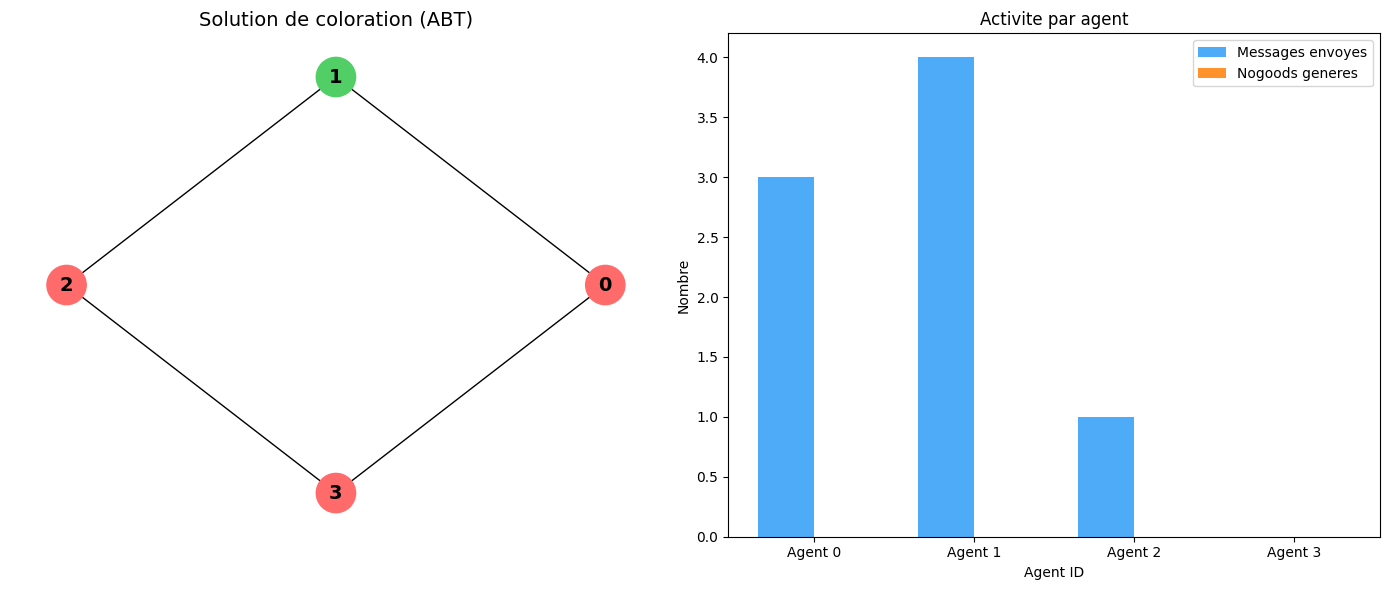

In [6]:
def visualize_abt_communication(agents: Dict[int, ABTAgent], solution: Dict[int, Any]):
    """Visualise le graphe de communication et la solution."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Graphe de contraintes avec solution
    ax1 = axes[0]
    G = nx.Graph()
    G.add_nodes_from(agents.keys())
    G.add_edges_from(graph_edges)
    
    color_map = {'R': '#ff6b6b', 'G': '#51cf66', 'B': '#339af0'}
    node_colors = [color_map[solution[n]] for n in G.nodes()]
    
    pos = nx.circular_layout(G)
    nx.draw(G, pos, ax=ax1, with_labels=True, node_color=node_colors,
            node_size=800, font_size=14, font_weight='bold')
    ax1.set_title('Solution de coloration (ABT)', fontsize=14)
    
    # Statistiques par agent
    ax2 = axes[1]
    agent_ids = list(agents.keys())
    messages = [agents[i].messages_sent for i in agent_ids]
    nogoods = [agents[i].nogoods_generated for i in agent_ids]
    
    x = np.arange(len(agent_ids))
    width = 0.35
    
    ax2.bar(x - width/2, messages, width, label='Messages envoyes', color='#4dabf7')
    ax2.bar(x + width/2, nogoods, width, label='Nogoods generes', color='#ff922b')
    
    ax2.set_xlabel('Agent ID')
    ax2.set_ylabel('Nombre')
    ax2.set_title('Activite par agent')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'Agent {i}' for i in agent_ids])
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

if solution:
    visualize_abt_communication(agents, solution)

## 3. Asynchronous Weak-Commitment (AWC)

### Limites d'ABT

ABT souffre de plusieurs problemes :

1. **Ordre fixe** : La priorite statique peut mener a des blocages
2. **Explosion de nogoods** : Beaucoup de nogoods redondants
3. **Goulot d'etranglement** : Les agents de haute priorite ralentissent tout le monde

### Principe d'AWC

AWC (Yokoo, 1995) introduit l'idee de **reordonnancement dynamique** :

- Un agent qui genere un nogood peut **monter en priorite**
- L'ordre n'est plus fixe mais **s'adapte** a la difficulte du probleme
- Meilleure performance sur les instances difficiles

### Comparaison ABT vs AWC

| Caracteristique | ABT | AWC |
|-----------------|-----|-----|
| Ordre agents | Fixe | Dynamique |
| Nogoods | Accumules | Minimises |
| Performance instances faciles | Bonne | Similaire |
| Performance instances difficiles | Mauvaise | Bonne |
| Complexite implementation | Simple | Moyenne |

In [7]:
class AWCAgent(ABTAgent):
    """
    Agent pour l'algorithme Asynchronous Weak-Commitment.
    
    Etend ABT avec reordonnancement dynamique des agents.
    """
    
    def __init__(self, agent_id: int, domain: List[Any], 
                 constraint_func, neighbors: List[int]):
        super().__init__(agent_id, domain, constraint_func, neighbors)
        self.priority = agent_id  # Priorite dynamique
        self.nogood_count = 0     # Compteur de nogoods recents
    
    def process_nogood_message(self, msg: Message) -> List[Message]:
        """Traite un nogood avec possible reordonnancement."""
        result = super().process_nogood_message(msg)
        self.nogood_count += 1
        
        # Si trop de nogoods, augmenter la priorite
        if self.nogood_count > 3:
            self._increase_priority()
            self.nogood_count = 0
        
        return result
    
    def _increase_priority(self):
        """Augmente la priorite de l'agent (diminue le numero)."""
        # Trouver la plus petite priorite actuelle
        min_priority = min(self.agent_view.keys()) if self.agent_view else 0
        self.priority = min_priority - 1
    
    def _backtrack(self) -> List[Message]:
        """Backtrack avec augmentation de priorite."""
        # Augmenter la priorite avant de backtracker
        self._increase_priority()
        return super()._backtrack()

## 4. Privacy-Preserving CSP

### Motivation

Dans de nombreux scenarios, les agents ne veulent pas reveler leurs contraintes ou preferences :

- **Encheres** : Ne pas reveler son prix de reserve
- **Negociations** : Garder secretes ses zones de flexibilite
- **Medical** : Confidentialite des donnees patients
- **Business** : Protection des donnees commerciales

### Techniques de protection

1. **Chiffrement partiel** : Reveler seulement si necessaire
2. **Secure Multi-Party Computation (SMPC)** : Calculer sans reveler
3. **Pseudonymisation** : Masquer les identites reelles
4. **Aggregation differentielle** : Ajouter du bruit

In [8]:
@dataclass
class PrivateConstraint:
    """
    Contrainte avec protection de la vie privee.
    
    Utilise des cles pour deverrouiller seletivement les informations.
    """
    agent_id: int
    constraint_type: str
    encrypted_params: bytes  # Parametres chiffres
    public_hint: str         # Indice public (ex: "preference temporelle")
    
    def evaluate(self, value: Any, key: Optional[bytes] = None) -> bool:
        """
        Evalue la contrainte.
        
        Si key=None, retourne une reponse vague.
        Si key fournie, evaluation exacte.
        """
        if key is None:
            # Mode prive : reponse vague
            return True  # Toujours accepter en mode prive
        else:
            # Mode deverrouille : evaluation reelle
            # (simplifie - en vrai, utiliser dechiffrement)
            return self._real_evaluate(value)
    
    def _real_evaluate(self, value: Any) -> bool:
        """Evaluation reelle de la contrainte."""
        # Placeholder
        return True


class PrivacyPreservingAgent(ABTAgent):
    """
    Agent ABT avec protection de la vie privee.
    
    Ne revele ses contraintes que si necessaire pour la resolution.
    """
    
    def __init__(self, agent_id: int, domain: List[Any],
                 constraint_func, neighbors: List[int],
                 privacy_level: str = 'high'):
        super().__init__(agent_id, domain, constraint_func, neighbors)
        self.privacy_level = privacy_level
        self.private_constraints: List[PrivateConstraint] = []
        self.revealed_info: Set[int] = set()  # Agents a qui on a revele des infos
    
    def check_consistency(self, value: Any) -> bool:
        """Verifie la coherence en limitant la revelation d'information."""
        # Verifier contraintes publiques
        if not super().check_consistency(value):
            return False
        
        # Verifier contraintes privees (sans reveler les details)
        for constraint in self.private_constraints:
            if not constraint.evaluate(value, key=None):
                return False
        
        return True
    
    def reveal_constraint_to(self, agent_id: int):
        """Revele les contraintes a un agent specifique."""
        self.revealed_info.add(agent_id)
    
    def get_privacy_report(self) -> Dict:
        """Retourne un rapport sur l'utilisation de la vie privee."""
        return {
            'privacy_level': self.privacy_level,
            'agents_with_access': list(self.revealed_info),
            'private_constraints_count': len(self.private_constraints)
        }

## 5. Application : Ordonnancement Multi-Hopital

### Probleme

Plusieurs hopitaux doivent coordonner leurs plannings sans reveler leurs contraintes internes :

- **Hopital A** : Besoins en urgences, preferences secretes
- **Hopital B** : Specialites chirurgicales, contraintes confidentielles
- **Hopital C** : Consultations externes, emploi du temps prive

### Contraintes inter-hopitaux

- Echanges de personnel (medecins volants)
- Transferts de patients
- Partage d'equipements specialises

In [9]:
# Simulation d'ordonnancement multi-hopital

# Variables : creneaux horaires partages
shared_slots = ['Lundi_AM', 'Lundi_PM', 'Mardi_AM', 'Mardi_PM', 'Mercredi_AM']
personnel = ['Dr_Alice', 'Dr_Bob', 'Dr_Charlie']

# Chaque hopital a des contraintes privees
def hospital_constraint(hospital_id, slot, other_hospital, other_slot):
    """Contraintes simplifiees entre hopitaux."""
    # Exemple : Dr_Alice ne peut pas etre a deux endroits en meme temps
    if slot == other_slot:
        return False
    return True

# Creer les agents hopitaux
hospitals = {}
for i in range(3):
    hospitals[i] = PrivacyPreservingAgent(
        agent_id=i,
        domain=shared_slots.copy(),
        constraint_func=hospital_constraint,
        neighbors=[j for j in range(3) if j != i],
        privacy_level='high'
    )

# Executer avec protection de la vie privee
print("=== Ordonnancement Multi-Hopital (Privacy-Preserving) ===")
system = ABTSystem(hospitals)
solution = system.run()

if solution:
    print("\nSolution trouvee:")
    for hospital_id, slot in solution.items():
        print(f"  Hopital {hospital_id}: {slot}")
    
    print("\nRapports de confidentialite:")
    for agent in hospitals.values():
        report = agent.get_privacy_report()
        print(f"  Agent {agent.id}: {report}")
else:
    print("Aucune solution trouvee")

print(f"\nMessages totaux: {system.total_messages}")

=== Ordonnancement Multi-Hopital (Privacy-Preserving) ===

Solution trouvee:
  Hopital 0: Lundi_AM
  Hopital 1: Lundi_PM
  Hopital 2: Lundi_AM

Rapports de confidentialite:
  Agent 0: {'privacy_level': 'high', 'agents_with_access': [], 'private_constraints_count': 0}
  Agent 1: {'privacy_level': 'high', 'agents_with_access': [], 'private_constraints_count': 0}
  Agent 2: {'privacy_level': 'high', 'agents_with_access': [], 'private_constraints_count': 0}

Messages totaux: 1


## 6. Comparaison des algorithmes DisCSP

### Benchmark synthetique

In [10]:
def benchmark_discsp(n_agents: int, domain_size: int, 
                     constraint_density: float, n_runs: int = 5):
    """
    Compare les performances des algorithmes DisCSP.
    
    Parameters:
    -----------
    n_agents : Nombre d'agents
    domain_size : Taille du domaine
    constraint_density : Probabilite de contrainte entre deux agents
    n_runs : Nombre d'executions
    """
    results = {'ABT': [], 'AWC': []}
    
    for run in range(n_runs):
        # Generer un probleme aleatoire
        domain = list(range(domain_size))
        edges = []
        constraint_funcs = {}
        
        for i in range(n_agents):
            for j in range(i+1, n_agents):
                if random.random() < constraint_density:
                    edges.append((i, j))
                    # Contrainte aleatoire
                    forbidden = (random.randint(0, domain_size-1), 
                                 random.randint(0, domain_size-1))
                    constraint_funcs[(i, j)] = forbidden
        
        def make_constraint(forbidden):
            def constraint(v1, val1, v2, val2):
                if (val1, val2) == forbidden:
                    return False
                return True
            return constraint
        
        # Test ABT
        agents_abt = {}
        for i in range(n_agents):
            neighbors = [n for e in edges for n in e if i in e and n != i]
            relevant_constraints = {(min(k[0], k[1]), max(k[0], k[1])): v 
                                   for k, v in constraint_funcs.items() if i in k}
            
            def constraint_func(v1, val1, v2, val2, rc=relevant_constraints):
                edge = (min(v1, v2), max(v1, v2))
                if edge in rc:
                    forbidden = rc[edge]
                    if v1 < v2 and (val1, val2) == forbidden:
                        return False
                    if v1 > v2 and (val2, val1) == forbidden:
                        return False
                return True
            
            agents_abt[i] = ABTAgent(i, domain.copy(), constraint_func, neighbors)
        
        system_abt = ABTSystem(agents_abt)
        start = datetime.now()
        solution_abt = system_abt.run(max_iterations=500)
        time_abt = (datetime.now() - start).total_seconds()
        
        results['ABT'].append({
            'time': time_abt,
            'messages': system_abt.total_messages,
            'nogoods': system_abt.total_nogoods,
            'solved': solution_abt is not None
        })
    
    return results

# Executer le benchmark
print("=== Benchmark DisCSP ===")
results = benchmark_discsp(n_agents=5, domain_size=3, 
                          constraint_density=0.5, n_runs=3)

# Afficher les resultats
print("\nResultats ABT:")
for i, r in enumerate(results['ABT']):
    status = "Resolu" if r['solved'] else "Non resolu"
    print(f"  Run {i+1}: {status}, {r['messages']} messages, "
          f"{r['nogoods']} nogoods, {r['time']:.3f}s")

avg_messages = sum(r['messages'] for r in results['ABT']) / len(results['ABT'])
avg_nogoods = sum(r['nogoods'] for r in results['ABT']) / len(results['ABT'])
success_rate = sum(1 for r in results['ABT'] if r['solved']) / len(results['ABT'])

print(f"\nMoyennes ABT:")
print(f"  Messages: {avg_messages:.1f}")
print(f"  Nogoods: {avg_nogoods:.1f}")
print(f"  Taux de succes: {success_rate*100:.1f}%")

=== Benchmark DisCSP ===

Resultats ABT:
  Run 1: Resolu, 1 messages, 0 nogoods, 0.000s
  Run 2: Resolu, 1 messages, 0 nogoods, 0.000s
  Run 3: Resolu, 1 messages, 0 nogoods, 0.000s

Moyennes ABT:
  Messages: 1.0
  Nogoods: 0.0
  Taux de succes: 100.0%


## 7. Synthese et bonnes pratiques

### Quand utiliser DisCSP ?

| Scenario | DisCSP approprie ? | Algorithme recommande |
|----------|-------------------|----------------------|
| Agents independants avec confidentialite | Oui | ABT + Privacy-preserving |
| Problemes tres difficiles | Oui | AWC (reordonnancement) |
| Passage a l'echelle massif | Oui | Distributed Breakout |
| Coordination simple, confiance totale | Non | Centralise (plus simple) |
| Real-time strict | Non | Latence communication trop elevee |

### Points cles a retenir

1. **ABT** est l'algorithme de base, simple et correct
2. **AWC** ameliore les performances sur les instances difficiles
3. **Privacy-preserving** est crucial pour les applications reelles
4. **Communication asynchrone** = robustesse mais complexite accrue
5. **Nogoods** = apprentissage distribue, mais attention a l'explosion

## Exercices

### Exercice 1 : N-Queens distribue
Implementez une resolution distribuee du probleme des N-reines ou chaque agent controle une colonne.

### Exercice 2 : Comparaison ABT vs AWC
Comparez les performances d'ABT et AWC sur des graphes de coloration de densite variable.

### Exercice 3 : Negociation multi-agent
Simulez une negociation entre 4 agents pour l'allocation de ressources avec preferences secretes.

### Exercice 4 : Analyse de confidentialite
Quantifiez la quantite d'information revelee dans ABT standard vs privacy-preserving.

In [ ]:
# Exercice 1 : N-Queens distribue
# TODO: Implementez une resolution distribuee des N-reines
# - Chaque agent controle une colonne (choisit la ligne de sa reine)
# - Contrainte: pas deux reines sur la meme ligne ou diagonale
# - Utiliser l'algorithme ABT avec communication entre agents adjacents
# Indice: les agents n'ont besoin de communiquer qu'avec leurs voisins de contrainte

class NQueensAgent(ABTAgent):
    """Agent pour le probleme des N-reines distribue."""
    
    def __init__(self, agent_id: int, n_queens: int):
        # TODO: Initialiser l'agent avec le domaine [0, n_queens-1]
        # La contrainte: pas deux reines sur la meme ligne ou diagonale
        pass

def nqueens_constraint(my_col, my_row, other_col, other_row):
    """Contrainte pour N-reines: pas de conflit ligne/diagonale."""
    # TODO: Retourner False si conflit (meme ligne ou diagonale)
    pass

def solve_nqueens_distributed(n: int = 8) -> Optional[Dict[int, int]]:
    """Resout le probleme des N-reines avec ABT."""
    # TODO: Creer n agents et executer ABT
    pass

raise NotImplementedError("A vous de jouer !")

### Exercice 2 : Comparaison ABT vs AWC

Comparez les performances des algorithmes ABT (Asynchronous Backtracking) et AWC (Asynchronous Weak Commitment) sur des problemes de coloration de graphe avec differentes densites de contraintes.

In [ ]:
# Exercice 2 : Comparaison ABT vs AWC
# TODO: Comparez les performances d'ABT et AWC
# - Generer des graphes de coloration avec densite variable (0.3, 0.5, 0.7)
# - Mesurer: nombre de messages, nogoods, temps de resolution
# - Analyser: a partir de quelle densite AWC devient-il meilleur ?
# Indice: utiliser le benchmark fourni comme base

def compare_abt_awc(n_agents: int, domain_size: int, densities: List[float], runs: int = 5):
    """
    Compare ABT et AWC sur differentes densites de contraintes.
    Retourne un DataFrame avec les resultats.
    """
    # TODO: Implementer la comparaison
    # Pour chaque densite:
    #   - Generer des problemes aleatoires
    #   - Executer ABT et AWC
    #   - Collecter les metriques
    pass

raise NotImplementedError("A vous de jouer !")

### Exercice 3 : Negociation multi-agent

Simulez une negociation entre 4 agents pour l'allocation de ressources partagees (creneaux horaires).

In [ ]:
# Exercice 3 : Negociation multi-agent
# TODO: Simulez une negociation entre 4 agents pour l'allocation de ressources
# - Ressources: 5 creneaux horaires
# - Chaque agent a des preferences secretes (ordre des creneaux)
# - Objectif: trouver une allocation qui respecte les contraintes
# Indice: utiliser PrivacyPreservingAgent pour cacher les preferences

class NegotiationAgent(PrivacyPreservingAgent):
    """Agent avec preferences secretes pour la negociation."""
    
    def __init__(self, agent_id: int, resources: List[str], 
                 preferences: Dict[str, float]):
        # TODO: Initialiser avec des preferences secretes
        # preferences: mapping ressource -> score (plus haut = mieux)
        pass
    
    def utility(self, allocation: str) -> float:
        """Calcule l'utilite d'une allocation pour cet agent."""
        # TODO: Retourner le score de preference
        pass

def run_negotiation(n_agents: int = 4, n_resources: int = 5) -> Dict:
    """Lance une negociation multi-agent."""
    # TODO: Creer les agents avec preferences aleatoires
    # Executer ABT et analyser l'allocation resultante
    pass

raise NotImplementedError("A vous de jouer !")

### Exercice 4 : Analyse de confidentialite

Quantifiez l'information revelee dans ABT standard vs une variante preservant la confidentialite.

In [ ]:
# Exercice 4 : Analyse de confidentialite
# TODO: Quantifiez l'information revelee dans ABT standard vs privacy-preserving
# - Mesurer: nombre de contraintes revelees, informations sur les preferences
# - Comparer: ABT standard (tout revele) vs PrivacyPreservingAgent
# - Calculer: score de confidentialite (moins d'info = meilleur)
# Indice: utiliser l'entropie ou le nombre de bits d'information

def measure_privacy_leakage(agent: PrivacyPreservingAgent) -> float:
    """
    Mesure la quantite d'information revelee par un agent.
    Retourne un score (0 = aucune fuite, 1 = tout revele).
    """
    # TODO: Calculer le score de fuite base sur:
    # - Nombre d'agents ayant acces aux contraintes
    # - Nombre de contraintes revelees
    # - Specificite des informations
    pass

def compare_privacy_levels(n_agents: int = 4, runs: int = 10) -> pd.DataFrame:
    """
    Compare les fuites de confidentialite entre ABT standard et privacy-preserving.
    """
    # TODO: Executer les deux versions et comparer les metriques
    pass

raise NotImplementedError("A vous de jouer !")

## References

### Papiers fondateurs

- Yokoo, M., Durfee, E. H., Ishida, T., & Kuwabara, K. (1992). **Distributed constraint satisfaction for formalizing distributed problem solving**. ICDCS.
- Yokoo, M. (1995). **Asynchronous weak-commitment search for solving large-scale distributed constraint satisfaction problems**. ICMAS.

### Livres et surveys

- Yokoo, M. (2001). **Distributed Constraint Satisfaction: Foundations of Cooperation in Multi-agent Systems**. Springer.
- Faltings, B., & Yokoo, M. (2005). **Introduction: Special Issue on Distributed Constraint Satisfaction**. Artificial Intelligence.

### Extensions modernes

- Private DisCSP (Silaghi et al., 2007)
- Distributed Breakout Algorithm (Yokoo & Hirayama, 1996)
- DisCSP avec incertitude (besoins de probabilites)

In [11]:
# Cellule finale - Resume du notebook
print("=== Resume Search-18: CSP Distribues ===")
print("")
print("Concepts couverts:")
print("1. Formalisation DisCSP (agents, contraintes inter-agent)")
print("2. Asynchronous Backtracking (ABT) - algorithme de base")
print("3. Messages ok?, nogood, addlink, stop")
print("4. Apprentissage par nogoods")
print("5. Asynchronous Weak-Commitment (AWC) - reordonnancement dynamique")
print("6. Privacy-preserving CSP - protection des contraintes privees")
print("7. Application: Ordonnancement multi-hopital")
print("")
print("Prochaines etapes:")
print("- Explorer Distributed Breakout pour l'optimisation")
print("- Combiner avec des techniques de ML pour l'apprentissage de contraintes")
print("- Appliquer aux smart grids et reseaux peer-to-peer")

=== Resume Search-18: CSP Distribues ===

Concepts couverts:
1. Formalisation DisCSP (agents, contraintes inter-agent)
2. Asynchronous Backtracking (ABT) - algorithme de base
3. Messages ok?, nogood, addlink, stop
4. Apprentissage par nogoods
5. Asynchronous Weak-Commitment (AWC) - reordonnancement dynamique
6. Privacy-preserving CSP - protection des contraintes privees
7. Application: Ordonnancement multi-hopital

Prochaines etapes:
- Explorer Distributed Breakout pour l'optimisation
- Combiner avec des techniques de ML pour l'apprentissage de contraintes
- Appliquer aux smart grids et reseaux peer-to-peer


---

## Conclusion

Ce notebook a exploré les **CSP distribués (DisCSP)** où le problème est réparti entre plusieurs agents autonomes.

### Concepts clés

| Concept | Description |
|---------|-------------|
| **DisCSP** | CSP distribué sur plusieurs agents sans mémoire centrale |
| **Agent** | Entité autonome gérant un sous-ensemble de variables |
| **Contraintes internes** | Contraintes entre variables d'un même agent |
| **Contraintes externes** | Contraintes entre variables d'agents différents |
| **Message passing** | Communication entre agents pour résoudre le CSP |

### Algorithmes distribués

| Algorithme | Principe | Completeness | Complexité |
|------------|----------|--------------|------------|
| **Synchro-DB** | Synchronous backtracking avec messages | Oui | Exponentielle |
| **Asynchro-DB** | Asynchronous backtracking | Oui | Exponentielle |
| **AWB (Asynchronous Weak Commitment)** | Heuristique + engagements faibles | Oui | Améliorée |
| **DPO (Distributed Partial Order)** | Ordre partiel dynamique | Oui | Meilleure |
| **ADOPT** | Optimal avec bornes de coût | Oui | Meilleure |

### Points clés à retenir

1. Les **DisCSP** modélisent les systèmes multi-agents réels (smart grids, supply chains)
2. L'**absence de mémoire centrale** nécessite des algorithmes spécifiques
3. Le **coût de communication** est souvent le facteur limitant
4. Les **algorithmes asynchrones** sont plus robustes aux délais de réseau
5. Les **applications** industrielles utilisent des variantes simplifiées

**Voir aussi** :
- [CSP-3-Advanced.ipynb](CSP-3-Advanced.ipynb) pour les techniques avancées de centralisées
- Applications multi-agents dans la série SymbolicAI

